In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customers = pd.read_csv(r"C:\Users\91776\Downloads\Olist-Ecommerce-Business-Analysis\data\olist_customers_dataset.csv")
geolocation = pd.read_csv(r"C:\Users\91776\Downloads\Olist-Ecommerce-Business-Analysis\data\olist_geolocation_dataset.csv")
orders = pd.read_csv(r"C:\Users\91776\Downloads\Olist-Ecommerce-Business-Analysis\data\olist_orders_dataset.csv")
order_items = pd.read_csv(r"C:\Users\91776\Downloads\Olist-Ecommerce-Business-Analysis\data\olist_order_items_dataset.csv")
payments = pd.read_csv(r"C:\Users\91776\Downloads\Olist-Ecommerce-Business-Analysis\data\olist_order_payments_dataset.csv")
reviews = pd.read_csv(r"C:\Users\91776\Downloads\Olist-Ecommerce-Business-Analysis\data\olist_order_reviews_dataset.csv")
products = pd.read_csv(r"C:\Users\91776\Downloads\Olist-Ecommerce-Business-Analysis\data\olist_products_dataset.csv")
sellers = pd.read_csv(r"C:\Users\91776\Downloads\Olist-Ecommerce-Business-Analysis\data\olist_sellers_dataset.csv")
category_translation = pd.read_csv(r"C:\Users\91776\Downloads\Olist-Ecommerce-Business-Analysis\data\product_category_name_translation.csv")

In [3]:
print("Customers:", customers.shape)
print("Geolocation:", geolocation.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Products:", products.shape)
print("Sellers:", sellers.shape)
print("Category Translation:", category_translation.shape)

Customers: (99441, 5)
Geolocation: (1000163, 5)
Orders: (99441, 8)
Order Items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)
Products: (32951, 9)
Sellers: (3095, 4)
Category Translation: (71, 2)


In [4]:
# Check the structure and data types of each dataset
datasets = {
    "Customers": customers,
    "Geolocation": geolocation,
    "Orders": orders,
    "Order Items": order_items,
    "Payments": payments,
    "Reviews": reviews,
    "Products": products,
    "Sellers": sellers,
    "Category Translation": category_translation
}

for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print("=" * 60)
    print(df.info())
    print()

Customers
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None

Geolocation
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city   

In [5]:
# Check missing values in each dataset
for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print("=" * 60)
    
    missing = df.isnull().sum()
    missing_percentage = (missing / len(df)) * 100
    
    missing_report = pd.DataFrame({
        "Missing Values": missing,
        "Missing Percentage": missing_percentage.round(2)
    })
    
    print(missing_report[missing_report["Missing Values"] > 0])
    print()

Customers
Empty DataFrame
Columns: [Missing Values, Missing Percentage]
Index: []

Geolocation
Empty DataFrame
Columns: [Missing Values, Missing Percentage]
Index: []

Orders
                               Missing Values  Missing Percentage
order_approved_at                         160                0.16
order_delivered_carrier_date             1783                1.79
order_delivered_customer_date            2965                2.98

Order Items
Empty DataFrame
Columns: [Missing Values, Missing Percentage]
Index: []

Payments
Empty DataFrame
Columns: [Missing Values, Missing Percentage]
Index: []

Reviews
                        Missing Values  Missing Percentage
review_comment_title             87656               88.34
review_comment_message           58247               58.70

Products
                            Missing Values  Missing Percentage
product_category_name                  610                1.85
product_name_lenght                    610                1.85
product_d

In [6]:
# Check duplicate rows in each dataset
for name, df in datasets.items():
    duplicate_count = df.duplicated().sum()
    
    print(f"{name}: {duplicate_count} duplicate rows")

Customers: 0 duplicate rows
Geolocation: 261831 duplicate rows
Orders: 0 duplicate rows
Order Items: 0 duplicate rows
Payments: 0 duplicate rows
Reviews: 0 duplicate rows
Products: 0 duplicate rows
Sellers: 0 duplicate rows
Category Translation: 0 duplicate rows


In [7]:
# Check how many unique ZIP-code prefixes exist
# compared with the total number of geolocation rows

print("Total rows:", len(geolocation))
print("Unique ZIP-code prefixes:", geolocation["geolocation_zip_code_prefix"].nunique())

Total rows: 1000163
Unique ZIP-code prefixes: 19015


In [8]:
# Check how many rows remain after removing exact duplicate rows
geolocation_unique = geolocation.drop_duplicates()

print("Original rows:", len(geolocation))
print("After removing exact duplicates:", len(geolocation_unique))
print("Duplicate rows removed:", len(geolocation) - len(geolocation_unique))

Original rows: 1000163
After removing exact duplicates: 738332
Duplicate rows removed: 261831


In [9]:
# Remove exact duplicate rows from the geolocation dataset while keeping the original dataframe unchanged

geolocation_clean = geolocation.drop_duplicates().copy()

print("Original rows:", len(geolocation))
print("Cleaned rows:", len(geolocation_clean))

Original rows: 1000163
Cleaned rows: 738332


In [10]:
# Check duplicate values in important identifier columns

key_columns = {
    "Customers": (customers, "customer_id"),
    "Orders": (orders, "order_id"),
    "Products": (products, "product_id"),
    "Sellers": (sellers, "seller_id")
}

for name, (df, column) in key_columns.items():
    duplicate_keys = df[column].duplicated().sum()
    
    print(f"{name} - {column}: {duplicate_keys} duplicate values")

Customers - customer_id: 0 duplicate values
Orders - order_id: 0 duplicate values
Products - product_id: 0 duplicate values
Sellers - seller_id: 0 duplicate values


In [11]:
# Check basic statistics for numerical columns
for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print("=" * 60)
    
    print(df.describe())
    print()

Customers
       customer_zip_code_prefix
count              99441.000000
mean               35137.474583
std                29797.938996
min                 1003.000000
25%                11347.000000
50%                24416.000000
75%                58900.000000
max                99990.000000

Geolocation
       geolocation_zip_code_prefix  geolocation_lat  geolocation_lng
count                 1.000163e+06     1.000163e+06     1.000163e+06
mean                  3.657417e+04    -2.117615e+01    -4.639054e+01
std                   3.054934e+04     5.715866e+00     4.269748e+00
min                   1.001000e+03    -3.660537e+01    -1.014668e+02
25%                   1.107500e+04    -2.360355e+01    -4.857317e+01
50%                   2.653000e+04    -2.291938e+01    -4.663788e+01
75%                   6.350400e+04    -1.997962e+01    -4.376771e+01
max                   9.999000e+04     4.506593e+01     1.211054e+02

Orders
                                order_id                    

In [12]:
# Check geolocation records with suspicious latitude values

suspicious_lat = geolocation[
    (geolocation["geolocation_lat"] < -35) |
    (geolocation["geolocation_lat"] > 5)
]

print("Suspicious latitude rows:", len(suspicious_lat))

suspicious_lat.head(10)

Suspicious latitude rows: 29


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
387565,18243,28.008978,-15.536867,bom retiro da esperanca,SP
513631,28165,41.614052,-8.411675,vila nova de campos,RJ
513754,28155,42.439286,13.820214,santa maria,RJ
514429,28333,38.381672,-6.328200,raposo,RJ
516682,28595,43.684961,-7.411080,portela,RJ
538512,29654,29.409252,-98.484121,santo antônio do canaã,ES
538557,29654,21.657547,-101.466766,santo antonio do canaa,ES
585242,35179,25.995203,-98.078544,santana do paraíso,MG
585260,35179,25.995245,-98.078533,santana do paraiso,MG
695377,45936,38.323939,-6.775035,itabatan,BA


In [13]:
# Check geolocation records with suspicious longitude values

suspicious_lng = geolocation[
    (geolocation["geolocation_lng"] < -75) |
    (geolocation["geolocation_lng"] > -30)
]

print("Suspicious longitude rows:", len(suspicious_lng))

suspicious_lng.head(10)

Suspicious longitude rows: 26


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
387565,18243,28.008978,-15.536867,bom retiro da esperanca,SP
513631,28165,41.614052,-8.411675,vila nova de campos,RJ
513754,28155,42.439286,13.820214,santa maria,RJ
514429,28333,38.381672,-6.328200,raposo,RJ
516682,28595,43.684961,-7.411080,portela,RJ
538512,29654,29.409252,-98.484121,santo antônio do canaã,ES
538557,29654,21.657547,-101.466766,santo antonio do canaa,ES
585242,35179,25.995203,-98.078544,santana do paraíso,MG
585260,35179,25.995245,-98.078533,santana do paraiso,MG
695377,45936,38.323939,-6.775035,itabatan,BA


In [14]:
# Check payment records with zero payment value

zero_payment = payments[payments["payment_value"] == 0]

print("Rows with zero payment value:", len(zero_payment))

zero_payment

Rows with zero payment value: 9


,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


In [15]:
# Check payment records with zero installments

zero_installments = payments[payments["payment_installments"] == 0]

print("Rows with zero installments:", len(zero_installments))

zero_installments

Rows with zero installments: 2


,order_id,payment_sequential,payment_type,payment_installments,payment_value
46982,744bade1fcf9ff3f31d860ace076d422,2,credit_card,0,58.69
79014,1a57108394169c0b47d8f876acc9ba2d,2,credit_card,0,129.94


In [16]:
# Check products with zero product weight

zero_weight = products[products["product_weight_g"] == 0]

print("Products with zero weight:", len(zero_weight))

zero_weight

Products with zero weight: 4


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
9769,81781c0fed9fe1ad6e8c81fca1e1cb08,cama_mesa_banho,51.0,529.0,1.0,0.0,30.0,25.0,30.0
13683,8038040ee2a71048d4bdbbdc985b69ab,cama_mesa_banho,48.0,528.0,1.0,0.0,30.0,25.0,30.0
14997,36ba42dd187055e1fbe943b2d11430ca,cama_mesa_banho,53.0,528.0,1.0,0.0,30.0,25.0,30.0
32079,e673e90efa65a5409ff4196c038bb5af,cama_mesa_banho,53.0,528.0,1.0,0.0,30.0,25.0,30.0


In [17]:
# Check products with zero or negative dimensions

invalid_dimensions = products[
    (products["product_length_cm"] <= 0) |
    (products["product_height_cm"] <= 0) |
    (products["product_width_cm"] <= 0)
]

print("Products with invalid dimensions:", len(invalid_dimensions))

invalid_dimensions

Products with invalid dimensions: 0


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm


In [18]:
# Convert order date columns from text to datetime format

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    orders[column] = pd.to_datetime(orders[column])
    
orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [19]:
# Create useful columns for business analysis

orders["order_month"] = orders["order_purchase_timestamp"].dt.to_period("M")
orders["order_year"] = orders["order_purchase_timestamp"].dt.year

orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.total_seconds() / (24 * 60 * 60)

orders[[
    "order_purchase_timestamp",
    "order_month",
    "order_year",
    "delivery_days",
    "delivery_delay_days"
]].head()

,order_purchase_timestamp,order_month,order_year,delivery_days,delivery_delay_days
0,2017-10-02 10:56:33,2017-10,2017,8.436574,-7.107488
1,2018-07-24 20:41:37,2018-07,2018,13.782037,-5.355729
2,2018-08-08 08:38:49,2018-08,2018,9.394213,-17.245498
3,2017-11-18 19:28:06,2017-11,2017,13.208750,-12.980069
4,2018-02-13 21:18:39,2018-02,2018,2.873877,-9.238171


In [20]:
# basic statistics of delivery metrics

orders[["delivery_days", "delivery_delay_days"]].describe()

,delivery_days,delivery_delay_days
count,96476.000000,96476.000000
mean,12.558702,-11.179120
std,9.546530,10.186113
min,0.533414,-146.016123
25%,6.766403,-16.244384
50%,10.217755,-11.948941
75%,15.720327,-6.390000
max,209.628611,188.975081


In [21]:
# Check for impossible negative delivery times

negative_delivery = orders[orders["delivery_days"] < 0]

print("Orders with negative delivery time:", len(negative_delivery))

Orders with negative delivery time: 0


In [22]:
# Monthly order volume

monthly_orders = (
    orders.groupby("order_month")["order_id"].nunique()
    .reset_index(name="total_orders")
)
monthly_orders.head(10)

,order_month,total_orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


In [23]:
# Monthly order volume — full period

monthly_orders

,order_month,total_orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


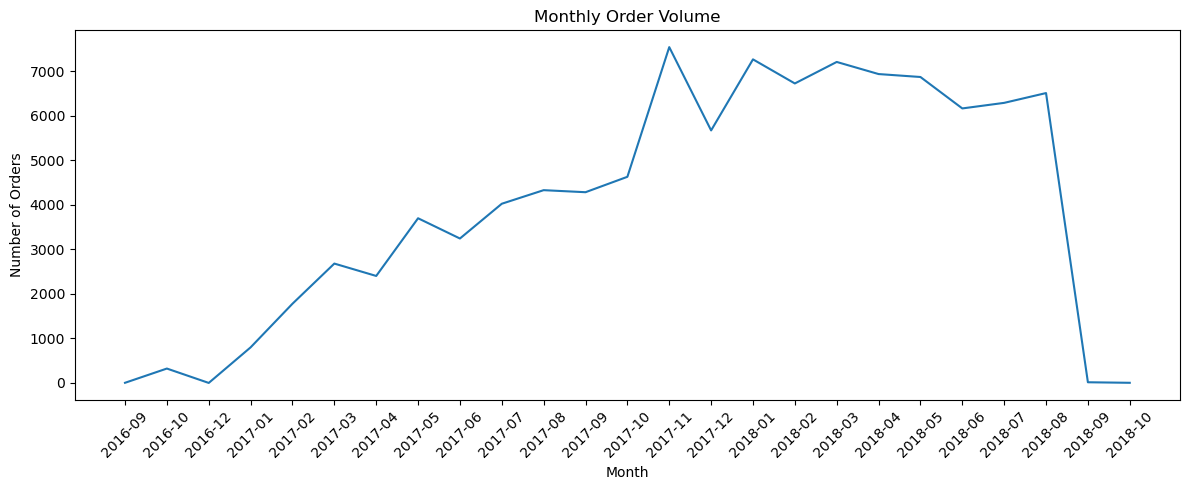

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_orders["order_month"].astype(str),
    monthly_orders["total_orders"]
)

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [25]:
# Calculate monthly payment value

monthly_revenue = (
    orders
    .merge(
        payments[["order_id", "payment_value"]],
        on="order_id",
        how="inner"
    )
    .groupby("order_month")["payment_value"]
    .sum()
    .reset_index(name="total_revenue")
)

monthly_revenue["total_revenue"] = monthly_revenue["total_revenue"].round(2)

monthly_revenue

,order_month,total_revenue
0,2016-09,252.24
1,2016-10,59090.48
2,2016-12,19.62
3,2017-01,138488.04
4,2017-02,291908.01
5,2017-03,449863.60
6,2017-04,417788.03
7,2017-05,592918.82
8,2017-06,511276.38
9,2017-07,592382.92


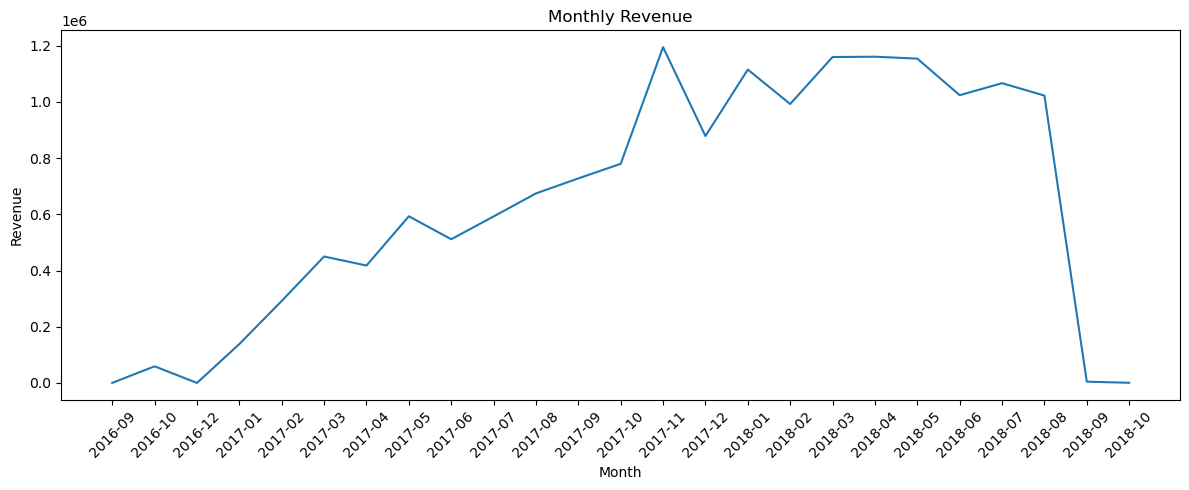

In [26]:
# Monthly revenue visualization

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["order_month"].astype(str),
    monthly_revenue["total_revenue"]
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [27]:
# Calculate sales value by product category

category_sales = (
    order_items
    .merge(
        products[["product_id", "product_category_name"]],
        on="product_id",
        how="left"
    )
    .groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index(name="sales_value")
)

category_sales.head(10)

,product_category_name,sales_value
0,beleza_saude,1258681.34
1,relogios_presentes,1205005.68
2,cama_mesa_banho,1036988.68
3,esporte_lazer,988048.97
4,informatica_acessorios,911954.32
5,moveis_decoracao,729762.49
6,cool_stuff,635290.85
7,utilidades_domesticas,632248.66
8,automotivo,592720.11
9,ferramentas_jardim,485256.46


In [28]:
# Add English category names using the translation table

category_sales = category_sales.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

category_sales["category"] = category_sales[
    "product_category_name_english"
].fillna(category_sales["product_category_name"])

category_sales.head(10)

,product_category_name,sales_value,product_category_name_english,category
0,beleza_saude,1258681.34,health_beauty,health_beauty
1,relogios_presentes,1205005.68,watches_gifts,watches_gifts
2,cama_mesa_banho,1036988.68,bed_bath_table,bed_bath_table
3,esporte_lazer,988048.97,sports_leisure,sports_leisure
4,informatica_acessorios,911954.32,computers_accessories,computers_accessories
5,moveis_decoracao,729762.49,furniture_decor,furniture_decor
6,cool_stuff,635290.85,cool_stuff,cool_stuff
7,utilidades_domesticas,632248.66,housewares,housewares
8,automotivo,592720.11,auto,auto
9,ferramentas_jardim,485256.46,garden_tools,garden_tools


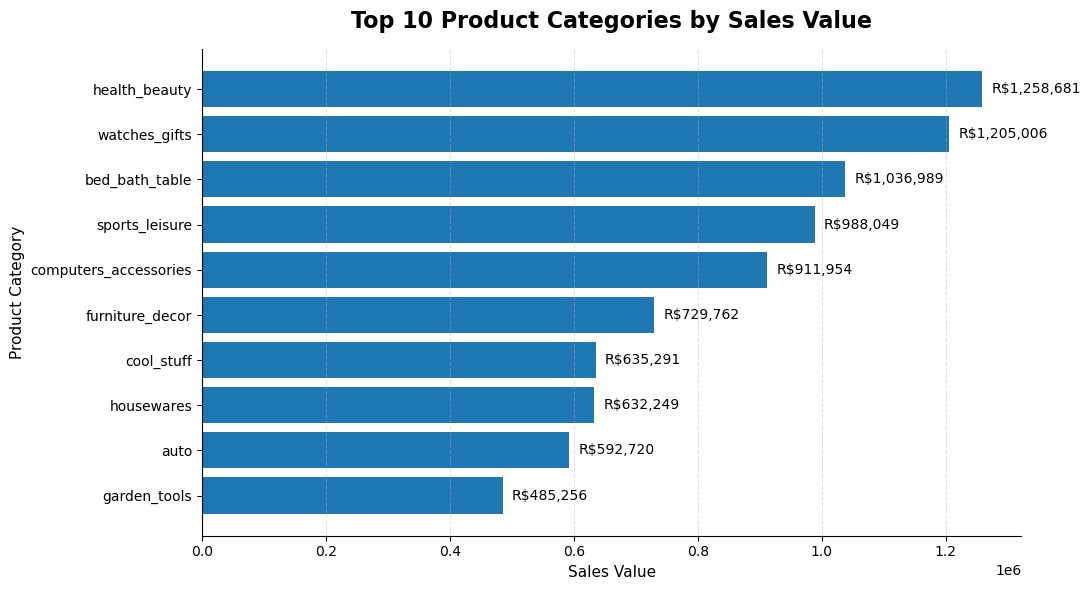

In [29]:
# Top 10 product categories by sales value

top_categories = category_sales.head(10).sort_values("sales_value")

plt.figure(figsize=(11, 6))

bars = plt.barh(
    top_categories["category"],
    top_categories["sales_value"]
)

# Add sales value labels to each bar
for bar in bars:
    width = bar.get_width()
    
    plt.text(
        width + 15000,
        bar.get_y() + bar.get_height() / 2,
        f"R${width:,.0f}",
        va="center",
        fontsize=10
    )

# Title and labels
plt.title(
    "Top 10 Product Categories by Sales Value",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Sales Value", fontsize=11)
plt.ylabel("Product Category", fontsize=11)

# Add subtle horizontal gridlines
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

# Remove unnecessary borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [30]:
# Calculate order volume by customer state

state_orders = (
    orders
    .merge(
        customers[["customer_id", "customer_state"]],
        on="customer_id",
        how="left"
    )
    .groupby("customer_state")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="total_orders")
)

state_orders

,customer_state,total_orders
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


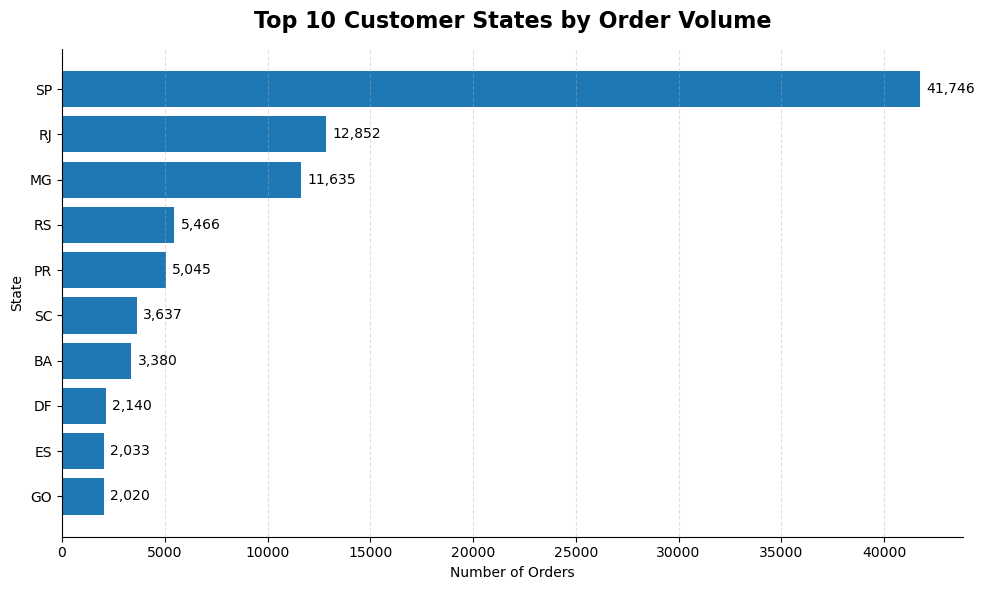

In [31]:
# Top 10 customer states by order volume

top_states = state_orders.head(10).sort_values("total_orders")

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_states["customer_state"],
    top_states["total_orders"]
)

# Add order-count labels
for bar in bars:
    width = bar.get_width()
    
    plt.text(
        width + 300,
        bar.get_y() + bar.get_height() / 2,
        f"{width:,.0f}",
        va="center",
        fontsize=10
    )

plt.title(
    "Top 10 Customer States by Order Volume",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Orders")
plt.ylabel("State")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [32]:
# Classify delivered orders as on-time or late

delivered_orders = orders[
    orders["order_delivered_customer_date"].notna()
].copy()

delivered_orders["delivery_status"] = delivered_orders["delivery_delay_days"].apply(
    lambda x: "Late" if x > 0 else "On Time"
)

delivery_status = (
    delivered_orders["delivery_status"]
    .value_counts()
    .reset_index()
)

delivery_status.columns = ["delivery_status", "total_orders"]

delivery_status

,delivery_status,total_orders
0,On Time,88649
1,Late,7827


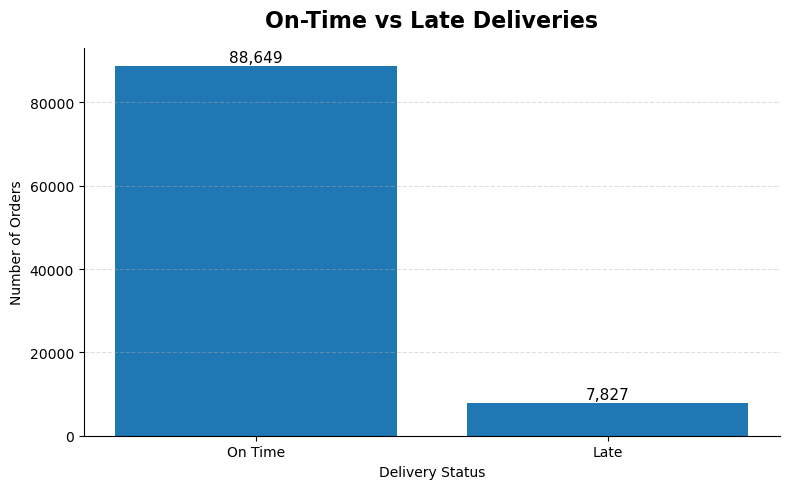

In [33]:
# Visualize on-time vs late deliveries

plt.figure(figsize=(8, 5))

bars = plt.bar(
    delivery_status["delivery_status"],
    delivery_status["total_orders"]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1000,
        f"{height:,.0f}",
        ha="center",
        fontsize=11
    )

plt.title(
    "On-Time vs Late Deliveries",
    fontsize=16,
    fontweight="bold",
    pad=15
)
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [34]:
# Summary statistics for delivery time

delivery_summary = delivered_orders["delivery_days"].describe()

delivery_summary

count    96476.000000
mean        12.558702
std          9.546530
min          0.533414
25%          6.766403
50%         10.217755
75%         15.720327
max        209.628611
Name: delivery_days, dtype: float64

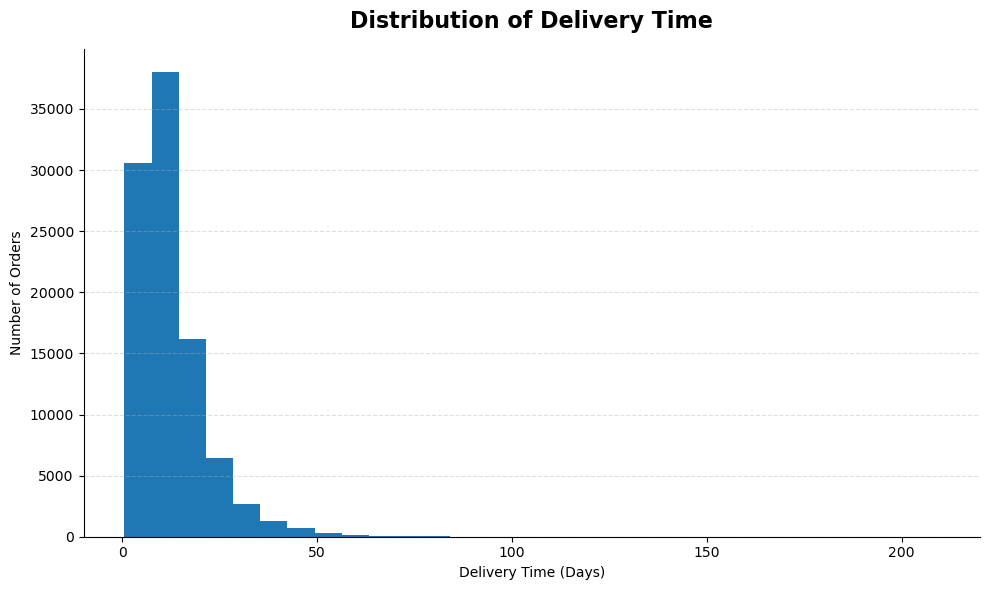

In [35]:
# Distribution of delivery time

plt.figure(figsize=(10, 6))

plt.hist(
    delivered_orders["delivery_days"],
    bins=30
)

plt.title(
    "Distribution of Delivery Time",
    fontsize=16,
    fontweight="bold",
    pad=15
)
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [36]:
# Identify the 10 longest delivery times

longest_deliveries = (
    delivered_orders[
        [
            "order_id",
            "order_status",
            "order_purchase_timestamp",
            "order_delivered_customer_date",
            "delivery_days"
        ]
    ]
    .sort_values("delivery_days", ascending=False)
    .head(10)
)

longest_deliveries

,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,delivery_days
19590,ca07593549f1816d26a572e06dc1eab6,delivered,2017-02-21 23:31:27,2017-09-19 14:36:39,209.628611
55619,1b3190b2dfa9d789e1f14c05b647a14a,delivered,2018-02-23 14:57:35,2018-09-19 23:24:07,208.351759
61610,440d0d17af552815d15a9e41abe49359,delivered,2017-03-07 23:59:51,2017-09-19 15:12:50,195.634016
70307,2fb597c2f772eca01b1f5c561bf6cc7b,delivered,2017-03-08 18:09:02,2017-09-19 14:33:17,194.850174
89130,285ab9426d6982034523a855f55a885e,delivered,2017-03-08 22:47:40,2017-09-19 14:00:04,194.633611
38509,0f4519c5f1c541ddec9f21b3bddd533a,delivered,2017-03-09 13:26:57,2017-09-19 14:38:21,194.049583
11399,47b40429ed8cce3aee9199792275433f,delivered,2018-01-03 09:44:01,2018-07-13 20:51:31,191.463542
81401,2fe324febf907e3ea3f2aa9650869fa5,delivered,2017-03-13 20:17:10,2017-09-19 17:00:07,189.863160
54480,2d7561026d542c8dbd8f0daeadf67a43,delivered,2017-03-15 11:24:27,2017-09-19 14:38:18,188.134618
68769,c27815f7e3dd0b926b58552628481575,delivered,2017-03-15 23:23:17,2017-09-19 17:14:25,187.743843


In [37]:
# Count orders with very long delivery times

long_delivery_counts = {
    "Over 30 days": (delivered_orders["delivery_days"] > 30).sum(),
    "Over 60 days": (delivered_orders["delivery_days"] > 60).sum(),
    "Over 90 days": (delivered_orders["delivery_days"] > 90).sum(),
    "Over 120 days": (delivered_orders["delivery_days"] > 120).sum()
}

long_delivery_counts

{'Over 30 days': 4553,
 'Over 60 days': 306,
 'Over 90 days': 77,
 'Over 120 days': 43}

In [38]:
# Calculate average delivery time and late-delivery rate by customer state

state_delivery = (
    delivered_orders
    .merge(
        customers[["customer_id", "customer_state"]],
        on="customer_id",
        how="left"
    )
    .groupby("customer_state")
    .agg(
        total_orders=("order_id", "nunique"),
        avg_delivery_days=("delivery_days", "mean"),
        late_orders=("delivery_status", lambda x: (x == "Late").sum())
    )
    .reset_index()
)

state_delivery["late_rate"] = (
    state_delivery["late_orders"] /
    state_delivery["total_orders"] * 100
)

state_delivery = state_delivery.sort_values(
    "late_rate",
    ascending=False
)

state_delivery

,customer_state,total_orders,avg_delivery_days,late_orders,late_rate
1,AL,397,24.543855,95,23.929471
9,MA,717,21.572976,141,19.665272
16,PI,476,19.457098,76,15.966387
5,CE,1279,21.266579,196,15.324472
24,SE,335,21.519788,51,15.223881
4,BA,3256,19.335466,457,14.035627
18,RJ,12353,15.310053,1664,13.470412
26,TO,274,17.658063,35,12.773723
13,PA,946,23.772917,117,12.367865
7,ES,1995,15.789307,244,12.230576


In [39]:
# Compare delivery performance for states with at least 1,000 delivered orders

major_states = (
    state_delivery[
        state_delivery["total_orders"] >= 1000
    ]
    .sort_values("late_rate", ascending=False)
)

major_states

,customer_state,total_orders,avg_delivery_days,late_orders,late_rate
5,CE,1279,21.266579,196,15.324472
4,BA,3256,19.335466,457,14.035627
18,RJ,12353,15.310053,1664,13.470412
7,ES,1995,15.789307,244,12.230576
15,PE,1593,18.448323,172,10.797238
23,SC,3547,14.959297,346,9.754722
8,GO,1957,15.606339,160,8.175779
22,RS,5344,15.300276,382,7.148204
6,DF,2080,12.967568,147,7.067308
25,SP,40495,8.761357,2387,5.894555


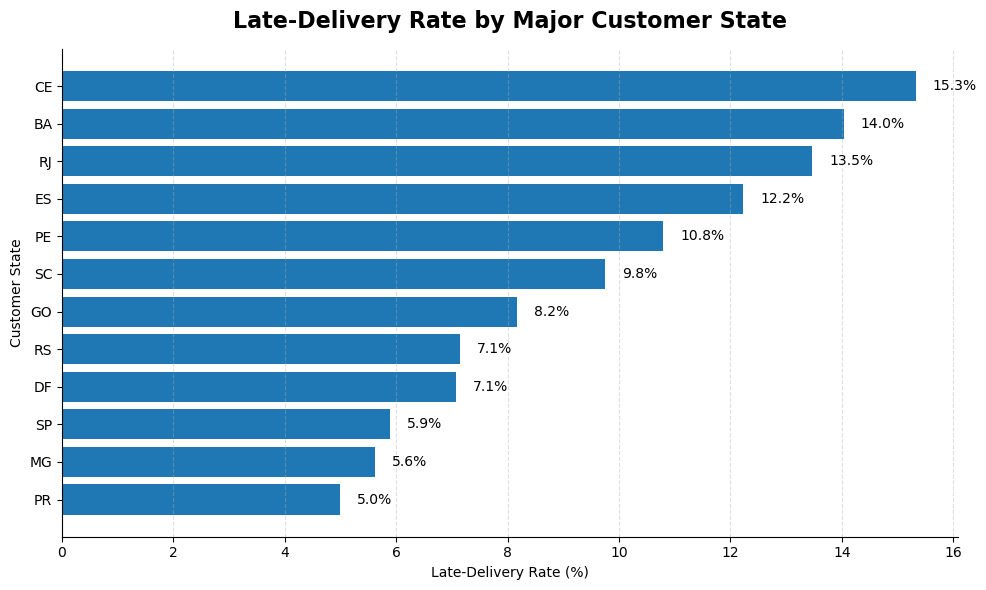

In [40]:
# Late-delivery rate across major customer states

plot_data = major_states.sort_values("late_rate")

plt.figure(figsize=(10, 6))

bars = plt.barh(
    plot_data["customer_state"],
    plot_data["late_rate"]
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        fontsize=10
    )

plt.title(
    "Late-Delivery Rate by Major Customer State",
    fontsize=16,
    fontweight="bold",
    pad=15
)
plt.xlabel("Late-Delivery Rate (%)")
plt.ylabel("Customer State")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [41]:
# Average review score for on-time vs late deliveries

delivery_reviews = (
    delivered_orders
    .merge(
        reviews[["order_id", "review_score"]],
        on="order_id",
        how="inner"
    )
    .groupby("delivery_status")["review_score"]
    .mean()
    .reset_index(name="average_review_score")
)

delivery_reviews["average_review_score"] = (
    delivery_reviews["average_review_score"].round(2)
)

delivery_reviews

,delivery_status,average_review_score
0,Late,2.57
1,On Time,4.29


In [42]:
# Top product categories by number of items sold

category_orders = (
    order_items
    .merge(
        products[["product_id", "product_category_name"]],
        on="product_id",
        how="left"
    )
    .groupby("product_category_name")
    .size()
    .reset_index(name="total_orders")
    .sort_values("total_orders", ascending=False)
    .head(10)
)

category_orders

,product_category_name,total_orders
13,cama_mesa_banho,11115
11,beleza_saude,9670
32,esporte_lazer,8641
54,moveis_decoracao,8334
44,informatica_acessorios,7827
72,utilidades_domesticas,6964
66,relogios_presentes,5991
70,telefonia,4545
40,ferramentas_jardim,4347
8,automotivo,4235


In [43]:
# Top product categories by revenue

category_revenue = (
    order_items
    .merge(
        products[["product_id", "product_category_name"]],
        on="product_id",
        how="left"
    )
    .groupby("product_category_name")["price"]
    .sum()
    .reset_index(name="total_revenue")
    .sort_values("total_revenue", ascending=False)
    .head(10)
)

category_revenue["total_revenue"] = (
    category_revenue["total_revenue"].round(2)
)

category_revenue

,product_category_name,total_revenue
11,beleza_saude,1258681.34
66,relogios_presentes,1205005.68
13,cama_mesa_banho,1036988.68
32,esporte_lazer,988048.97
44,informatica_acessorios,911954.32
54,moveis_decoracao,729762.49
26,cool_stuff,635290.85
72,utilidades_domesticas,632248.66
8,automotivo,592720.11
40,ferramentas_jardim,485256.46


In [44]:
# Payment method analysis

payment_analysis = (
    payments
    .groupby("payment_type")
    .agg(
        total_payments=("order_id", "count"),
        total_value=("payment_value", "sum")
    )
    .reset_index()
    .sort_values("total_payments", ascending=False)
)

payment_analysis["total_value"] = (
    payment_analysis["total_value"].round(2)
)

payment_analysis

,payment_type,total_payments,total_value
1,credit_card,76795,12542084.19
0,boleto,19784,2869361.27
4,voucher,5775,379436.87
2,debit_card,1529,217989.79
3,not_defined,3,0.00


In [45]:
# Top sellers by number of items sold

seller_performance = (
    order_items
    .groupby("seller_id")
    .agg(
        total_items_sold=("order_id", "count"),
        total_revenue=("price", "sum")
    )
    .reset_index()
    .sort_values("total_items_sold", ascending=False)
    .head(10)
)

seller_performance["total_revenue"] = (
    seller_performance["total_revenue"].round(2)
)

seller_performance

,seller_id,total_items_sold,total_revenue
1235,6560211a19b47992c3666cc44a7e94c0,2033,123304.83
881,4a3ca9315b744ce9f8e9374361493884,1987,200472.92
368,1f50f920176fa81dab994f9023523100,1931,106939.21
2481,cc419e0650a3c5ba77189a1882b7556a,1775,104288.42
2643,da8622b14eb17ae2831f4ac5b9dab84a,1551,160236.57
1824,955fee9216a65b617aa5c0531780ce60,1499,135171.70
192,1025f0e2d44d7041d6cf58b6550e0bfa,1428,138968.55
1535,7c67e1448b00f6e969d365cea6b010ab,1364,187923.89
2836,ea8482cd71df3c1969d7b9473ff13abc,1203,37177.52
1505,7a67c85e85bb2ce8582c35f2203ad736,1171,141745.53
